# Dose-response: does MedGemma follow the anatomy?

**Questions** (PLAN.md, checks after the first audit and the day-4 decision rule).
1. Cardiomegaly: as the heart is enlarged step by step (grown-heart mask at 6 strengths, from the
   heart's own outline to the audit's +30%), where does each model switch to "yes", measured in
   CTR, and is that near the clinical 0.5? Same question on all real PA test films.
2. Effusion: does blurring the lung bases (no RadEdit) raise P(yes)? If so, the sham drift can be
   lost normal detail meeting the "yes" prior rather than a RadEdit trace.
3. Are the scores deterministic (re-scored images against the audit)?

**Switch point.** A logistic curve of P(yes) against the measured CTR (segmenter), fitted with
P(yes) as a soft label (each film counts as "yes" with weight P(yes) and "no" with weight
1 - P(yes)). The switch point is the CTR where the curve crosses 0.5; 95% CI by resampling
patients. Step 2 of the day-4 rule applies if the CI for the edited films does not overlap
0.47-0.53.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

ROOT = Path.cwd().parent  # the notebook runs from notebooks/
sys.path.insert(0, str(ROOT))
from cxr.data import ACCENT, AXIS, GRID, INK, INK_2, MUTED, SURFACE

R = ROOT / "results"
models = ["4b", "1.5-4b"]
measures = pd.read_csv(R / "dose_measures.csv")
keys = ["group", "finding", "image", "level"]
scores = {m: pd.read_csv(R / f"dose_scores_{m}.csv").merge(
    measures.drop(columns="patient_id"), on=keys, how="left") for m in models}
audit = {m: pd.read_csv(R / f"audit_{m}_test.csv") for m in models}
thresholds = {m: pd.read_csv(R / f"audit_{m}_thresholds.csv") for m in models}
print(measures.groupby(["group", "finding"], dropna=False).size().to_string())

group     finding     
blur      effusion         200
dose      cardiomegaly     600
original  effusion         100
real      cardiomegaly    1883
sham      effusion         100


## 1. Determinism: re-scored images against the audit

In [2]:
rows = []
for m in models:
    s, a = scores[m], audit[m]
    for name, mine, theirs in [
        ("real originals (cardiomegaly)", s[(s["group"] == "real")], a[(a["finding"] == "cardiomegaly") & (a["variant"] == "original")]),
        ("+30% edits", s[(s["group"] == "dose") & (s["level"] == 0.30)], a[(a["finding"] == "cardiomegaly") & (a["variant"] == "edit")]),
        ("effusion originals", s[(s["group"] == "original")], a[(a["finding"] == "effusion") & (a["variant"] == "original")]),
        ("effusion shams", s[(s["group"] == "sham")], a[(a["finding"] == "effusion") & (a["variant"] == "sham")])]:
        j = mine.merge(theirs[["image", "phrasing", "log_odds", "p_yes"]], on=["image", "phrasing"], suffixes=("", "_audit"))
        rows.append({"model": m, "images": name, "n": len(j), "max_abs_diff_p_yes": np.abs(j["p_yes"] - j["p_yes_audit"]).max(),
                     "max_abs_diff_log_odds": np.abs(j["log_odds"] - j["log_odds_audit"]).max(),
                     "share_identical_log_odds": (j["log_odds"] == j["log_odds_audit"]).mean()})
determinism = pd.DataFrame(rows)
determinism.to_csv(R / "dose_determinism.csv", index=False)
determinism

,model,images,n,max_abs_diff_p_yes,max_abs_diff_log_odds,share_identical_log_odds
0,4b,real originals (cardiomegaly),760,0.000002,0.062046,0.997368
1,4b,+30% edits,200,0.000000,0.000000,1.000000
2,4b,effusion originals,200,0.000000,0.000000,1.000000
3,4b,effusion shams,200,0.000000,0.000000,1.000000
4,1.5-4b,real originals (cardiomegaly),760,0.000354,0.069727,0.997368
5,1.5-4b,+30% edits,200,0.000000,0.000000,1.000000
6,1.5-4b,effusion originals,200,0.000000,0.000000,1.000000
7,1.5-4b,effusion shams,200,0.000000,0.000000,1.000000


## 2. Cardiomegaly dose-response: what each strength did to the film

In [3]:
d = measures[measures["group"] == "dose"]
effect = d.groupby("level").agg(n=("image", "size"), ctr_median=("ctr", "median"),
                                share_ctr_above_05=("ctr", lambda x: (x > 0.5).mean()),
                                classifier_median=("classifier_cardiomegaly", "median")).reset_index()
originals = measures[(measures["group"] == "real") & measures["image"].isin(d["image"])]
effect = pd.concat([pd.DataFrame([{"level": "original", "n": len(originals), "ctr_median": originals["ctr"].median(),
                                   "share_ctr_above_05": (originals["ctr"] > 0.5).mean(),
                                   "classifier_median": originals["classifier_cardiomegaly"].median()}]), effect], ignore_index=True)
for m in models:
    for phrasing in [0, 1]:
        s = scores[m][scores[m]["phrasing"] == phrasing]
        orig = s[(s["group"] == "real") & s["image"].isin(d["image"])]
        dose = s[s["group"] == "dose"]
        effect[f"p_yes_median_{m}_q{phrasing}"] = [orig["p_yes"].median()] + dose.groupby("level")["p_yes"].median().tolist()
        effect[f"share_yes_{m}_q{phrasing}"] = [(orig["log_odds"] > 0).mean()] + dose.groupby("level")["log_odds"].apply(lambda x: (x > 0).mean()).tolist()
effect.to_csv(R / "dose_effect_by_growth.csv", index=False)
effect.round(3).T

,0,1,2,3,4,5,6
level,original,0.0,0.06,0.12,0.18,0.24,0.3
n,100,100,100,100,100,100,100
ctr_median,0.43,0.434,0.456,0.48,0.505,0.528,0.55
share_ctr_above_05,0.0,0.01,0.08,0.27,0.53,0.72,0.82
classifier_median,0.023,0.046,0.109,0.277,0.507,0.536,0.586
p_yes_median_4b_q0,0.0,0.003,0.905,1.0,1.0,1.0,1.0
share_yes_4b_q0,0.14,0.39,0.54,0.76,0.81,0.92,0.97
p_yes_median_4b_q1,0.0,0.0,0.0,0.053,1.0,1.0,1.0
share_yes_4b_q1,0.04,0.09,0.23,0.47,0.72,0.79,0.9
p_yes_median_1.5-4b_q0,0.011,0.086,0.849,1.0,1.0,1.0,1.0


## 3. Switch points: P(yes) against the measured CTR

In [4]:
def fit(d):
    """Logistic curve of P(yes) on CTR with P(yes) as a soft label; returns (switch point, slope)."""
    x = np.concatenate([d["ctr"], d["ctr"]])[:, None]
    y = np.concatenate([np.ones(len(d)), np.zeros(len(d))])
    w = np.concatenate([d["p_yes"], 1 - d["p_yes"]])
    lr = LogisticRegression(C=1e6, max_iter=1000).fit(x, y, sample_weight=w)
    a, b = lr.intercept_[0], lr.coef_[0, 0]
    return -a / b, b

def switch_ci(d, n_boot=1000, seed=0):
    groups = [g.index.to_numpy() for _, g in d.groupby("patient_id")]
    rng = np.random.default_rng(seed)
    boots = [fit(d.loc[np.concatenate([groups[i] for i in rng.integers(len(groups), size=len(groups))])])[0]
             for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])

rows, fits = [], {}
for m in models:
    s = scores[m]
    for films, sel in [("edited", s["group"] == "dose"), ("real", s["group"] == "real")]:
        for phrasing in [0, 1]:
            d = s[sel & (s["phrasing"] == phrasing) & s["ctr"].notna()].reset_index(drop=True)
            point, slope = fit(d)
            lo, hi = switch_ci(d)
            fits[(m, films, phrasing)] = (point, slope)
            rows.append({"model": m, "films": films, "phrasing": phrasing, "n": len(d), "patients": d["patient_id"].nunique(),
                         "switch_ctr": point, "ci_low": lo, "ci_high": hi, "slope_per_ctr_unit": slope,
                         "ci_overlaps_0.47_0.53": bool(hi >= 0.47 and lo <= 0.53)})
switch = pd.DataFrame(rows)
switch.to_csv(R / "dose_switch_points.csv", index=False)
switch.round(3)

,model,films,phrasing,n,patients,switch_ctr,ci_low,ci_high,slope_per_ctr_unit,ci_overlaps_0.47_0.53
0,4b,edited,0,600,100,0.446,0.438,0.452,59.889,False
1,4b,edited,1,600,100,0.482,0.476,0.488,61.113,True
2,4b,real,0,1880,974,0.505,0.492,0.521,29.407,True
3,4b,real,1,1880,974,0.560,0.541,0.584,27.002,False
4,1.5-4b,edited,0,600,100,0.444,0.437,0.450,60.306,False
5,1.5-4b,edited,1,600,100,0.470,0.464,0.475,59.503,True
6,1.5-4b,real,0,1880,974,0.485,0.478,0.493,32.227,True
7,1.5-4b,real,1,1880,974,0.534,0.518,0.554,26.283,True


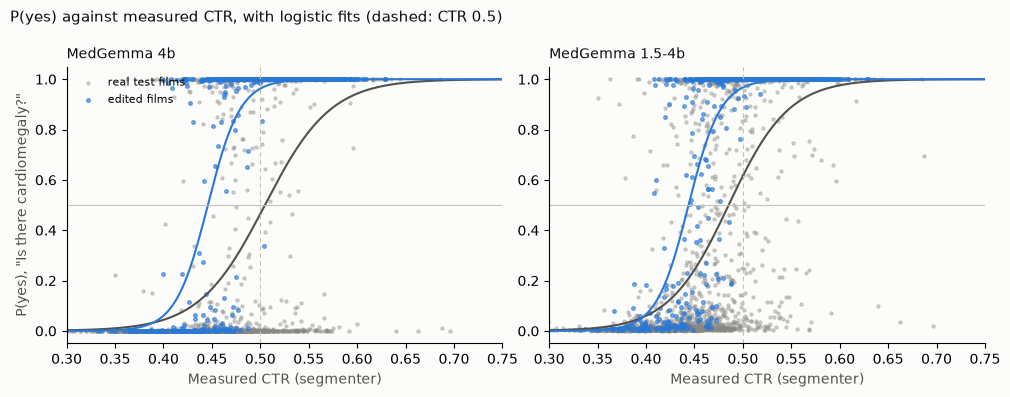

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), facecolor=SURFACE, squeeze=False)
grid = np.linspace(0.3, 0.75, 200)
for ax, m in zip(axes[0], models):
    s = scores[m][scores[m]["phrasing"] == 0]
    real, edited = s[s["group"] == "real"], s[s["group"] == "dose"]
    ax.scatter(real["ctr"], real["p_yes"], s=5, color=MUTED, alpha=0.35, label="real test films")
    ax.scatter(edited["ctr"], edited["p_yes"], s=7, color=ACCENT, alpha=0.6, label="edited films")
    for films, color in [("real", INK_2), ("edited", ACCENT)]:
        point, slope = fits[(m, films, 0)]
        ax.plot(grid, 1 / (1 + np.exp(-slope * (grid - point))), color=color, linewidth=1.5)
    ax.axvline(0.5, color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.axhline(0.5, color=AXIS, linewidth=0.8)
    ax.set_xlim(0.3, 0.75)
    ax.set_xlabel("Measured CTR (segmenter)", color=INK_2)
    ax.set_title(f"MedGemma {m}", loc="left", color=INK, fontsize=10)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylabel('P(yes), "Is there cardiomegaly?"', color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("P(yes) against measured CTR, with logistic fits (dashed: CTR 0.5)", x=0.01, ha="left", color=INK, fontsize=11)
fig.tight_layout()
fig.savefig(R / "dose_psychometric.png", dpi=200, facecolor=SURFACE)
plt.show()

## 4. Effusion evidence-loss control

The lung-base mask blurred at two strengths, no RadEdit, on the first 100 effusion source films
of the audit; the originals and RadEdit shams of the same films for comparison. Change in log-odds
against the original, with a 95% CI over films (one film per patient).

In [6]:
rows = []
for m in models:
    s = scores[m][scores[m]["finding"] == "effusion"]
    thr = thresholds[m].set_index(["finding", "phrasing"])["threshold_log_odds"]
    for phrasing in [0, 1]:
        p = s[s["phrasing"] == phrasing]
        base = p[p["group"] == "original"].set_index("image")
        for name, sel in [("original", p["group"] == "original"), ("blur sigma 3", (p["group"] == "blur") & (p["level"] == 3)),
                          ("blur sigma 8", (p["group"] == "blur") & (p["level"] == 8)), ("RadEdit sham", p["group"] == "sham")]:
            g = p[sel].set_index("image")
            delta = (g["log_odds"] - base.loc[g.index, "log_odds"]).to_numpy()
            rng = np.random.default_rng(0)
            boots = [delta[rng.integers(len(delta), size=len(delta))].mean() for _ in range(1000)]
            rows.append({"model": m, "phrasing": phrasing, "images": name, "n": len(g),
                         "median_p_yes": g["p_yes"].median(), "share_above_threshold": (g["log_odds"] > thr[("effusion", phrasing)]).mean(),
                         "mean_change_log_odds": delta.mean(), "ci_low": np.percentile(boots, 2.5), "ci_high": np.percentile(boots, 97.5),
                         "median_lung_area_in_mask": g["lung_area_in_mask"].median()})
blur = pd.DataFrame(rows)
blur.to_csv(R / "dose_effusion_blur.csv", index=False)
blur.round(3)

,model,phrasing,images,n,median_p_yes,share_above_threshold,mean_change_log_odds,ci_low,ci_high,median_lung_area_in_mask
0,4b,0,original,100,0.000,0.07,0.000,0.000,0.000,19440.0
1,4b,0,blur sigma 3,100,0.000,0.15,0.472,0.157,0.867,18735.5
2,4b,0,blur sigma 8,100,0.000,0.63,4.892,3.749,6.138,14344.0
3,4b,0,RadEdit sham,100,0.000,0.11,0.193,-0.355,0.659,19473.0
4,4b,1,original,100,0.000,0.19,0.000,0.000,0.000,19440.0
5,4b,1,blur sigma 3,100,0.000,0.29,0.649,0.256,1.093,18735.5
6,4b,1,blur sigma 8,100,0.001,0.85,6.843,5.489,8.286,14344.0
7,4b,1,RadEdit sham,100,0.000,0.28,0.796,0.236,1.394,19473.0
8,1.5-4b,0,original,100,0.006,0.11,0.000,0.000,0.000,19440.0
9,1.5-4b,0,blur sigma 3,100,0.009,0.22,0.881,0.582,1.263,18735.5


## 5. Blank and shuffled images: share of "yes" for both models (audit controls)

In [7]:
controls = pd.read_csv(R / "audit_controls.csv")
controls[controls["variant"].isin(["blank", "shuffled"])].pivot_table(
    index=["finding", "phrasing", "variant"], columns="model", values=["share_above_05", "share_above_threshold", "max_p_yes"]).round(4)

max_p_yes         share_above_05       \
model                             1.5-4b      4b         1.5-4b   4b   
finding      phrasing variant                                          
cardiomegaly 0        blank       0.0044  0.0004            0.0  0.0   
                      shuffled    0.0931  0.0007            0.0  0.0   
             1        blank       0.0012  0.0003            0.0  0.0   
                      shuffled    0.0165  0.0005            0.0  0.0   
effusion     0        blank       0.0030  0.0002            0.0  0.0   
                      shuffled    0.0254  0.0000            0.0  0.0   
             1        blank       0.0045  0.0009            0.0  0.0   
                      shuffled    0.0340  0.0005            0.0  0.0   

                               share_above_threshold          
model                                         1.5-4b      4b  
finding      phrasing variant                                 
cardiomegaly 0        blank                   0.0000  0.0000  
                      shuffled                0.0000  0.0000  
             1        blank                   0.0000  0.9947  
                      shuffled                0.0000  0.2711  
effusion     0        blank                   0.0000  1.0000  
                      shuffled                0.0033  0.5050  
             1        blank                   0.0000  1.0000  
                      shuffled                0.0000  0.5750

## 6. Real and edited films at the same measured CTR

An edited-film switch point is not a CTR threshold (P(yes) jumps at the first growth step), so
the write-up compares P(yes) on real and edited films inside the same CTR band. Difference =
edited - real, 95% CI resampling patients jointly: a patient's real and edited films are drawn
together, since the edited films come from patients who also have real films in the band.

In [8]:
bands = [0.40, 0.44, 0.48, 0.52, 0.56]
def boot_diff(edited, real, col, rng, n_boot=1000):
    """Bootstrap differences mean(edited) - mean(real), resampling patients jointly: a drawn patient
    brings all its edited and real films, so the patients in both groups stay paired."""
    patients = np.union1d(edited["patient_id"].unique(), real["patient_id"].unique())
    rows_e = {p: g[col].to_numpy() for p, g in edited.groupby("patient_id")}
    rows_r = {p: g[col].to_numpy() for p, g in real.groupby("patient_id")}
    diffs = []
    for _ in range(n_boot):
        draw = patients[rng.integers(len(patients), size=len(patients))]
        xe, xr = [rows_e[p] for p in draw if p in rows_e], [rows_r[p] for p in draw if p in rows_r]
        if xe and xr:
            diffs.append(np.concatenate(xe).mean() - np.concatenate(xr).mean())
    return diffs

rows = []
for m in models:
    s = scores[m]
    for phrasing in [0, 1]:
        p = s[(s["phrasing"] == phrasing) & s["group"].isin(["real", "dose"])].copy()
        p["band"] = pd.cut(p["ctr"], bands, right=False)
        for band, g in p.groupby("band", observed=True):
            real, edited = g[g["group"] == "real"], g[g["group"] == "dose"]
            if len(real) < 5 or len(edited) < 5:
                continue
            diffs = boot_diff(edited, real, "p_yes", np.random.default_rng(0))
            rows.append({"model": m, "phrasing": phrasing, "ctr_band": str(band), "n_real": len(real),
                         "n_edited": len(edited), "mean_p_yes_real": real["p_yes"].mean(),
                         "mean_p_yes_edited": edited["p_yes"].mean(),
                         "difference": edited["p_yes"].mean() - real["p_yes"].mean(),
                         "ci_low": np.percentile(diffs, 2.5), "ci_high": np.percentile(diffs, 97.5)})
matched = pd.DataFrame(rows).round(3)
matched.to_csv(R / "dose_matched_ctr.csv", index=False)
matched

,model,phrasing,ctr_band,n_real,n_edited,mean_p_yes_real,mean_p_yes_edited,difference,ci_low,ci_high
0,4b,0,"[0.4, 0.44)",409,86,0.044,0.264,0.220,0.124,0.335
1,4b,0,"[0.44, 0.48)",486,145,0.221,0.661,0.441,0.356,0.529
2,4b,0,"[0.48, 0.52)",355,142,0.536,0.982,0.446,0.376,0.512
3,4b,0,"[0.52, 0.56)",200,125,0.696,1.000,0.304,0.160,0.448
4,4b,1,"[0.4, 0.44)",409,86,0.002,0.013,0.011,-0.002,0.037
5,4b,1,"[0.44, 0.48)",486,145,0.046,0.252,0.206,0.126,0.289
6,4b,1,"[0.48, 0.52)",355,142,0.224,0.728,0.504,0.411,0.591
7,4b,1,"[0.52, 0.56)",200,125,0.384,0.979,0.594,0.464,0.695
8,1.5-4b,0,"[0.4, 0.44)",409,86,0.076,0.258,0.182,0.084,0.287
9,1.5-4b,0,"[0.44, 0.48)",486,145,0.319,0.701,0.383,0.297,0.465


## 7. Phrasing effect on real films

Switch point of "Is the heart enlarged?" minus that of "Is there cardiomegaly?", on the same real
films; the CI resamples patients once for both phrasings (paired).

In [9]:
rows = []
for m in models:
    s = scores[m]
    real = s[(s["group"] == "real") & s["ctr"].notna()]
    wide = real.pivot_table(index=["image", "patient_id", "ctr"], columns="phrasing", values="p_yes").reset_index()
    def diff(d):
        return (fit(d.rename(columns={1: "p_yes"}))[0] - fit(d.rename(columns={0: "p_yes"}))[0])
    groups = [g.index.to_numpy() for _, g in wide.groupby("patient_id")]
    rng = np.random.default_rng(0)
    boots = [diff(wide.loc[np.concatenate([groups[i] for i in rng.integers(len(groups), size=len(groups))])])
             for _ in range(1000)]
    rows.append({"model": m, "n_films": len(wide), "switch_phrasing_0": fit(wide.rename(columns={0: "p_yes"}))[0],
                 "switch_phrasing_1": fit(wide.rename(columns={1: "p_yes"}))[0], "difference_1_minus_0": diff(wide),
                 "ci_low": np.percentile(boots, 2.5), "ci_high": np.percentile(boots, 97.5)})
phrasing_effect = pd.DataFrame(rows).round(3)
phrasing_effect.to_csv(R / "dose_phrasing_effect.csv", index=False)
phrasing_effect

,model,n_films,switch_phrasing_0,switch_phrasing_1,difference_1_minus_0,ci_low,ci_high
0,4b,1880,0.505,0.560,0.055,0.044,0.067
1,1.5-4b,1880,0.485,0.534,0.048,0.037,0.065


## 8. Effusion: does MedGemma move where the segmenter does not?

Per film, the relative change of the aerated lung area inside the lung-base mask under blur
(segmenter), next to MedGemma's change in log-odds. Films are split by whether the segmenter's
lung area fell by less than 5% (the edit check needs 10%).

In [10]:
area = measures[measures["finding"] == "effusion"].pivot_table(index="image", columns=["group", "level"],
                                                                 values="lung_area_in_mask")
rows = []
for m in models:
    s = scores[m][scores[m]["finding"] == "effusion"]
    for phrasing in [0, 1]:
        p = s[s["phrasing"] == phrasing]
        base = p[p["group"] == "original"].set_index("image")["log_odds"]
        for sigma in [3.0, 8.0]:
            b = p[(p["group"] == "blur") & (p["level"] == sigma)].set_index("image")["log_odds"]
            change = (area[("blur", sigma)] / area[("original", 0.0)] - 1).loc[b.index]
            dlo = b - base.loc[b.index]
            small = change > -0.05
            rng = np.random.default_rng(0)
            x = dlo[small].to_numpy()
            boots = [x[rng.integers(len(x), size=len(x))].mean() for _ in range(1000)] if len(x) else [np.nan]
            rows.append({"model": m, "phrasing": phrasing, "blur_sigma": sigma,
                         "median_lung_area_change": change.median(), "share_change_above_-5%": small.mean(),
                         "n_small_change": int(small.sum()), "mean_change_log_odds_small": x.mean() if len(x) else np.nan,
                         "ci_low": np.percentile(boots, 2.5), "ci_high": np.percentile(boots, 97.5),
                         "mean_change_log_odds_all": dlo.mean()})
blur_area = pd.DataFrame(rows)
blur_area.to_csv(R / "dose_blur_lung_area.csv", index=False)
blur_area.round(3)

,model,phrasing,blur_sigma,median_lung_area_change,share_change_above_-5%,n_small_change,mean_change_log_odds_small,ci_low,ci_high,mean_change_log_odds_all
0,4b,0,3.0,-0.019,0.78,78,0.462,0.167,0.931,0.472
1,4b,0,8.0,-0.241,0.16,16,4.242,2.116,6.922,4.892
2,4b,1,3.0,-0.019,0.78,78,0.646,0.220,1.204,0.649
3,4b,1,8.0,-0.241,0.16,16,8.289,4.861,11.957,6.843
4,1.5-4b,0,3.0,-0.019,0.78,78,0.791,0.564,1.058,0.881
5,1.5-4b,0,8.0,-0.241,0.16,16,6.599,4.352,8.832,4.852
6,1.5-4b,1,3.0,-0.019,0.78,78,0.656,0.445,0.902,0.703
7,1.5-4b,1,8.0,-0.241,0.16,16,5.285,3.257,7.316,3.466


## 9. Do the two questions agree? (item 12, 2026-09-30)

Per film: "yes" (P > 0.5) to "Is there cardiomegaly?" and "no" to "Is the heart enlarged?", or the
reverse, on real test films and at each growth of the dose edits.

In [11]:
rows = []
for m in models:
    s = scores[m][scores[m]["group"].isin(["real", "dose"])].assign(level=lambda x: x["level"].fillna(-1))  # real films: no growth
    w = s.pivot_table(index=["group", "image", "level"], columns="phrasing", values="log_odds").reset_index()
    w["level"] = np.where(w["group"] == "real", "real films", w["level"].map(lambda v: f"growth {v:.2f}"))
    for level, g in w.groupby("level", sort=False):
        rows.append({"model": m, "films": level, "n": len(g),
                     "yes_cardiomegaly_no_enlarged": ((g[0] > 0) & (g[1] <= 0)).mean(),
                     "no_cardiomegaly_yes_enlarged": ((g[0] <= 0) & (g[1] > 0)).mean(),
                     "share_yes_cardiomegaly": (g[0] > 0).mean(), "share_yes_enlarged": (g[1] > 0).mean()})
contradiction = pd.DataFrame(rows)
contradiction.to_csv(R / "dose_phrasing_contradiction.csv", index=False)
contradiction.round(3)

,model,films,n,yes_cardiomegaly_no_enlarged,no_cardiomegaly_yes_enlarged,share_yes_cardiomegaly,share_yes_enlarged
0,4b,growth 0.00,100,0.300,0.0,0.390,0.090
1,4b,growth 0.06,100,0.310,0.0,0.540,0.230
2,4b,growth 0.12,100,0.290,0.0,0.760,0.470
3,4b,growth 0.18,100,0.090,0.0,0.810,0.720
4,4b,growth 0.24,100,0.130,0.0,0.920,0.790
5,4b,growth 0.30,100,0.070,0.0,0.970,0.900
6,4b,real films,1883,0.161,0.0,0.288,0.127
7,1.5-4b,growth 0.00,100,0.280,0.0,0.380,0.100
8,1.5-4b,growth 0.06,100,0.210,0.0,0.540,0.330
9,1.5-4b,growth 0.12,100,0.190,0.0,0.760,0.570


## Takeaways

In [12]:
for _, r in switch[switch["phrasing"] == 0].iterrows():
    print(f"MedGemma {r['model']}, {r['films']} films: switch to 'yes' at CTR {r['switch_ctr']:.3f} "
          f"(95% CI {r['ci_low']:.3f}-{r['ci_high']:.3f}); overlaps 0.47-0.53: {r['ci_overlaps_0.47_0.53']}.")
step2 = switch[(switch["films"] == "edited") & ~switch["ci_overlaps_0.47_0.53"]]
print("Step 2 applies for:", sorted(set(step2["model"])) or "no model")
for _, r in blur[blur["images"] != "original"].iterrows():
    print(f"MedGemma {r['model']}, phrasing {r['phrasing']}, {r['images']}: log-odds change {r['mean_change_log_odds']:+.2f} "
          f"(95% CI {r['ci_low']:+.2f} to {r['ci_high']:+.2f}).")
print("Re-scored images against the audit: largest log-odds difference", round(determinism["max_abs_diff_log_odds"].max(), 5),
      "; smallest share identical", round(determinism["share_identical_log_odds"].min(), 4))

MedGemma 4b, edited films: switch to 'yes' at CTR 0.446 (95% CI 0.438-0.452); overlaps 0.47-0.53: False.
MedGemma 4b, real films: switch to 'yes' at CTR 0.505 (95% CI 0.492-0.521); overlaps 0.47-0.53: True.
MedGemma 1.5-4b, edited films: switch to 'yes' at CTR 0.444 (95% CI 0.437-0.450); overlaps 0.47-0.53: False.
MedGemma 1.5-4b, real films: switch to 'yes' at CTR 0.485 (95% CI 0.478-0.493); overlaps 0.47-0.53: True.
Step 2 applies for: ['1.5-4b', '4b']
MedGemma 4b, phrasing 0, blur sigma 3: log-odds change +0.47 (95% CI +0.16 to +0.87).
MedGemma 4b, phrasing 0, blur sigma 8: log-odds change +4.89 (95% CI +3.75 to +6.14).
MedGemma 4b, phrasing 0, RadEdit sham: log-odds change +0.19 (95% CI -0.35 to +0.66).
MedGemma 4b, phrasing 1, blur sigma 3: log-odds change +0.65 (95% CI +0.26 to +1.09).
MedGemma 4b, phrasing 1, blur sigma 8: log-odds change +6.84 (95% CI +5.49 to +8.29).
MedGemma 4b, phrasing 1, RadEdit sham: log-odds change +0.80 (95% CI +0.24 to +1.39).
MedGemma 1.5-4b, phrasing